In [1]:
from pathlib import Path
import dask.dataframe as dd
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [13]:
YEAR = 2022
CHUNKS_FOLDERPATH = Path(F"../data/silver/ghana-{YEAR}-chunks")
DF_FILEPATH = Path(F'../data/silver/ghana-{YEAR}-df.parquet')

# Load data

In [14]:
ddf = dd.read_parquet(CHUNKS_FOLDERPATH / "*.parquet")
print("# rows:", len(ddf))

# rows: 254321


In [15]:
# Load a sample 
N_SAMPLE = 20_000
ddf.sample(frac=N_SAMPLE/len(ddf))
df = ddf.compute().reset_index(drop=True)

/tmp/ipykernel_32169/2487668675.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='lon', y='lat', palette='tab20', s=1, alpha=0.5, edgecolor=None)


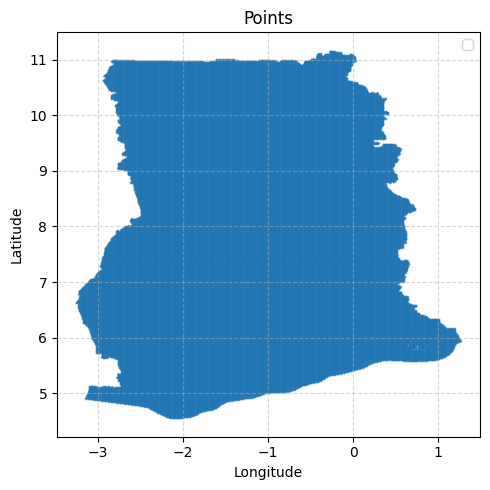

In [16]:
# Plot the data
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x='lon', y='lat', palette='tab20', s=1, alpha=0.5, edgecolor=None)

plt.title('Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Cleanup

In [17]:
# Cleanup
df = df.rename(columns={'ethz_map': 'y'})
df['y'] = df.y > 0.65 # max F1 as per the ETHZ paper
df.head(1)

,lon,lat,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,...,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence_11x11_median,cloud_confidence_11x11_min,cloud_confidence_11x11_max,cloud_confidence_11x11_var,scene_classification,valid_observations,y
0,-0.273906,11.165903,31,32,31,35,1,33,31,37,...,0,0,0,0,0,0,0,5,5,False


In [18]:
# Convert bands to 0-1 values
band_cols = [e for e in df.columns if e not in ('lon', 'lat', 'y')]
band_cols = [e for e in band_cols if not any(e.startswith(prefix) for prefix in ('cloud_confidence', 'scene_classification', 'valid_observations'))]
df[band_cols] /= 255
df.head(1)

,lon,lat,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,...,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence_11x11_median,cloud_confidence_11x11_min,cloud_confidence_11x11_max,cloud_confidence_11x11_var,scene_classification,valid_observations,y
0,-0.273906,11.165903,0.121569,0.12549,0.121569,0.137255,0.003922,0.129412,0.121569,0.145098,...,0,0,0,0,0,0,0,5,5,False


# Figure out in which region each point is

In [19]:
# Figure out in which region each point is
import pandas as pd
import geopandas as gpd

gdf_points = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['lon'], df['lat']), crs="EPSG:4326")

ghana_regions = gpd.read_file('../data/bronze/gadm41_GHA.gpkg', layer='ADM_ADM_1')
ghana_regions = ghana_regions.to_crs("EPSG:4326")

# Spatial join
joined = gpd.sjoin(gdf_points, ghana_regions, how="left", predicate="within")

# Fix slightly out-of-bound
matched = joined[joined['NAME_1'].notna()]
unmatched = joined[joined['NAME_1'].isna()].copy()

if not unmatched.empty:
    # Drop the empty columns from the unsuccessful join to avoid duplicates
    cols_to_drop = ghana_regions.columns.drop('geometry').tolist() + ['index_right']
    unmatched_clean = unmatched.drop(columns=cols_to_drop, errors='ignore')

    # IMPORTANT: Use unmatched_clean here!
    unmatched_fixed = gpd.sjoin_nearest(unmatched_clean, ghana_regions, how="left", distance_col="distance")

    # Recombine the matched and the newly fixed unmatched points
    joined = pd.concat([matched, unmatched_fixed])

# Finally, assign the result back to your original dataframe
df['region'] = joined['NAME_1'].astype('category')

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(
/tmp/ipykernel_32169/113184014.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['region'] = joined['NAME_1'].astype('category')


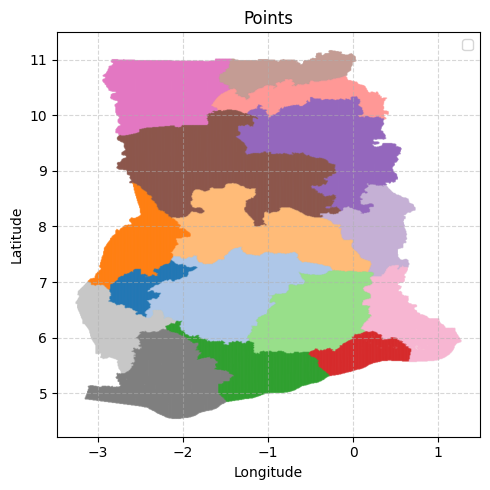

In [20]:
# Plot the data
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x='lon', y='lat', hue='region', palette='tab20', s=1, alpha=0.5, edgecolor=None)

plt.title('Points')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Feature engineering

In [21]:
# SCL
# The SCL flags a lot of px as cloud and whatnot, but not vegetation
SCL_IDX_TO_SCL_NAME = {
    0: 'NO_DATA',
    1: 'DEFECTIVE_PX',
    2: 'TOPO_SHADOW',
    3: 'CLOUD_SHADOW',
    4: 'VEGETATION',
    5: 'NOT_VEGETATED',
    6: 'WATER',
    7: 'UNCLASSIFIED',
    8: 'CLOUD_MED_PROB',
    9: 'CLOUD_HIGH_PROB',
    10: 'THIN_CIRRUS',
    11: 'SNOW_OR_ICE',
}

df['scl'] = df.scene_classification.map(SCL_IDX_TO_SCL_NAME).astype('category')
df = df.drop(columns=['scene_classification']).copy()
df.head(1)

/tmp/ipykernel_32169/3624374248.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['scl'] = df.scene_classification.map(SCL_IDX_TO_SCL_NAME).astype('category')


,lon,lat,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,...,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence_11x11_median,cloud_confidence_11x11_min,cloud_confidence_11x11_max,cloud_confidence_11x11_var,valid_observations,y,region,scl
0,-0.273906,11.165903,0.121569,0.12549,0.121569,0.137255,0.003922,0.129412,0.121569,0.145098,...,0,0,0,0,0,0,5,False,Upper East,NOT_VEGETATED


In [22]:
# TCI & others

def compute_tci(df, suffix):
    return 1.2 * (df[f"rededge{suffix}"] - df[f"green{suffix}"]) - 1.5 * (df[f"red{suffix}"] - df[f"green{suffix}"]) * np.sqrt(df[f"rededge{suffix}"] / df[f"red{suffix}"])

def compute_ndvi(df, suffix):
    return (df[f"nir{suffix}"] - df[f"red{suffix}"]) / (df[f"nir{suffix}"] + df[f"red{suffix}"])

def compute_evi(df, suffix):
    G, C1, C2, L = 2.5, 6, 7.5, 1.0
    return G * (df[f"nir{suffix}"] - df[f"red{suffix}"]) / (df[f"nir{suffix}"] + C1 * df[f"red{suffix}"] + C2 * df[f"blue{suffix}"] + L)

def compute_evi2(df, suffix):
    return (df[f"nir{suffix}"] - df[f"swir11{suffix}"]) / (df[f"nir{suffix}"] + df[f"swir11{suffix}"])

def compute_ndre_b5(df, suffix):
    return (df[f"B8A{suffix}"] - df[f"rededge{suffix}"]) / (df[f"B8A{suffix}"] + df[f"rededge{suffix}"])

def compute_ndre_b6(df, suffix):
    return (df[f"B8A{suffix}"] - df[f"B06{suffix}"]) / (df[f"B8A{suffix}"] + df[f"B06{suffix}"])

def compute_ndre_b7(df, suffix):
    return (df[f"B8A{suffix}"] - df[f"B07{suffix}"]) / (df[f"B8A{suffix}"] + df[f"B07{suffix}"])

def compute_gndvi(df, suffix):
    return 2.5 * (df[f"nir{suffix}"] - df[f"red{suffix}"]) / (df[f"nir{suffix}"] + 2.4 * df[f"red{suffix}"] + 1) 

def compute_ndwi(df, suffix):
    return (df[f"nir{suffix}"] - df[f"swir11{suffix}"]) / (df[f"nir{suffix}"] + df[f"swir11{suffix}"])

df["tci"] = compute_tci(df, '').copy()
df["ndvi"] = compute_ndvi(df, '').copy()
df["evi"] = compute_evi(df, '').copy()
df["evi2"] = compute_evi2(df, '').copy()
df["ndre_b5"] = compute_ndre_b5(df, '').copy()
df["ndre_b6"] = compute_ndre_b6(df, '').copy()
df["ndre_b7"] = compute_ndre_b7(df, '').copy()
df["gndvi"] = compute_gndvi(df, '').copy()
df["ndwi"] = compute_ndwi(df, '').copy()
df.head(1)

,lon,lat,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,...,scl,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi
0,-0.273906,11.165903,0.121569,0.12549,0.121569,0.137255,0.003922,0.129412,0.121569,0.145098,...,NOT_VEGETATED,0.042069,0.194805,0.062552,-0.163636,0.072165,0.083333,-0.009524,0.099893,-0.163636


# Dump

In [23]:
df.to_parquet(DF_FILEPATH)